In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%load_ext autoreload
%autoreload 2

np.random.seed(42)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generate Synthetic Neural Connectivity Data

Creates a biologically-plausible synthetic dataset of 500 neurons with modular pathway structure (Stochastic Block Model).

In [4]:
# =============================================================================
# 1. PARAMETERS - Network Architecture (Stochastic Block Model)
# =============================================================================
C = 500  # Total cells
CLUSTER_LABELS = ['A', 'B', 'C', 'D', 'E']
CLUSTER_SIZES = [120, 80, 150, 50, 100]  # Must sum to C

assert sum(CLUSTER_SIZES) == C, "Cluster sizes must sum to C"

# Connection probabilities (tuned for ~3-5% matrix density)
P_PATHWAY = 0.15     # Primary pathway: A→B, B→C, C→D, D→E
P_FEEDBACK = 0.03    # Feedback: E→A, C→A
P_BACKGROUND = 0.01  # Global noise for all other pairs

# Synapse properties
LOGNORMAL_SIGMA = 0.5  # sigma for lognormal(0, sigma)
WEIGHT_RANGE = (0.1, 1.0)
P_MULTI_SYNAPSE = 0.1  # 10% of pairs have 2-3 synapses

In [5]:
# =============================================================================
# 2. CLUSTER ASSIGNMENTS
# =============================================================================
# Assign each cell to a cluster (cell_id 0..C-1)
cell_ids = np.arange(C)
cluster_assignments = np.repeat(CLUSTER_LABELS, CLUSTER_SIZES)
cluster_df = pd.DataFrame({'cell_id': cell_ids, 'cluster_label': cluster_assignments})

# Mapping: cell_id -> cluster index (0..4)
cell_to_cluster_idx = {i: CLUSTER_LABELS.index(c) for i, c in zip(cell_ids, cluster_assignments)}

In [6]:
# =============================================================================
# 3. BUILD BINARY CONNECTIVITY (SBM) - which pairs are connected
# =============================================================================
def get_connection_prob(pre_cluster: str, post_cluster: str) -> float:
    """Return connection probability for pre_cluster -> post_cluster."""
    pathway_pairs = [('A','B'), ('B','C'), ('C','D'), ('D','E')]
    feedback_pairs = [('E','A'), ('C','A')]
    if (pre_cluster, post_cluster) in pathway_pairs:
        return P_PATHWAY
    if (pre_cluster, post_cluster) in feedback_pairs:
        return P_FEEDBACK
    return P_BACKGROUND

# Sample binary connections
connected_pairs = []  # List of (pre_id, post_id)
for i in range(C):
    for j in range(C):
        if i == j:  # No self-connections
            continue
        p = get_connection_prob(cluster_assignments[i], cluster_assignments[j])
        if np.random.random() < p:
            connected_pairs.append((i, j))

print(f"Number of connected pairs: {len(connected_pairs)}")
print(f"Matrix density (before weights): {100 * len(connected_pairs) / (C * (C - 1)):.2f}%")

Number of connected pairs: 7771
Matrix density (before weights): 3.11%


In [7]:
# =============================================================================
# 4. SYNAPSE WEIGHTS & MULTI-SYNAPSE
# =============================================================================
def sample_synapse_weight() -> float:
    """Sample weight from lognormal(0, sigma), scale to [0.1, 1.0]."""
    w = np.random.lognormal(mean=0, sigma=LOGNORMAL_SIGMA)
    # Lognormal(0, 0.5) ~95% in [~0.37, ~2.7]. Clip and min-max scale to [0.1, 1.0]
    lo, hi = 0.2, 3.0
    w = np.clip(w, lo, hi)
    return 0.1 + 0.9 * (w - lo) / (hi - lo)

# Build edge list: each row = one synapse (pre_id, post_id, synapse_size)
edges = []
for (pre, post) in connected_pairs:
    n_syn = 1 if np.random.random() >= P_MULTI_SYNAPSE else np.random.choice([2, 3])
    for _ in range(n_syn):
        w = sample_synapse_weight()
        edges.append((pre, post, w))

edge_df = pd.DataFrame(edges, columns=['pre_id', 'post_id', 'synapse_size'])
print(f"Total synapses (edges): {len(edge_df)}")
print(f"Unique connected pairs: {edge_df.groupby(['pre_id','post_id']).ngroups}")

Total synapses (edges): 8996
Unique connected pairs: 7771


In [8]:
# =============================================================================
# 5. CONNECTIVITY MATRIX (sum of weights per pair)
# =============================================================================
connectivity_matrix = np.zeros((C, C), dtype=float)
for _, row in edge_df.iterrows():
    connectivity_matrix[int(row['pre_id']), int(row['post_id'])] += row['synapse_size']

# Ensure diagonal is zero (no self-connections)
np.fill_diagonal(connectivity_matrix, 0)

n_connected = np.sum(connectivity_matrix > 0)
density = 100 * n_connected / (C * (C - 1))
print(f"Connected pairs in matrix: {n_connected}")
print(f"Matrix density: {density:.2f}% (target: 3-5%)")

Connected pairs in matrix: 7771
Matrix density: 3.11% (target: 3-5%)


In [9]:
# =============================================================================
# 6. SAVE DATA
# =============================================================================
DATA_DIR = '/data/toy_data' if os.path.exists('/data/toy_data') else '../data/toy_data'
os.makedirs(DATA_DIR, exist_ok=True)

# 1. edge_list.csv
edge_df.to_csv(os.path.join(DATA_DIR, 'edge_list.csv'), index=False)
print(f"Saved: {DATA_DIR}/edge_list.csv")

# 2. cluster_assignments.csv
cluster_df.to_csv(os.path.join(DATA_DIR, 'cluster_assignments.csv'), index=False)
print(f"Saved: {DATA_DIR}/cluster_assignments.csv")

# 3. connectivity_matrix.npy
np.save(os.path.join(DATA_DIR, 'connectivity_matrix.npy'), connectivity_matrix)
print(f"Saved: {DATA_DIR}/connectivity_matrix.npy")

Saved: ../data/toy_data/edge_list.csv
Saved: ../data/toy_data/cluster_assignments.csv
Saved: ../data/toy_data/connectivity_matrix.npy


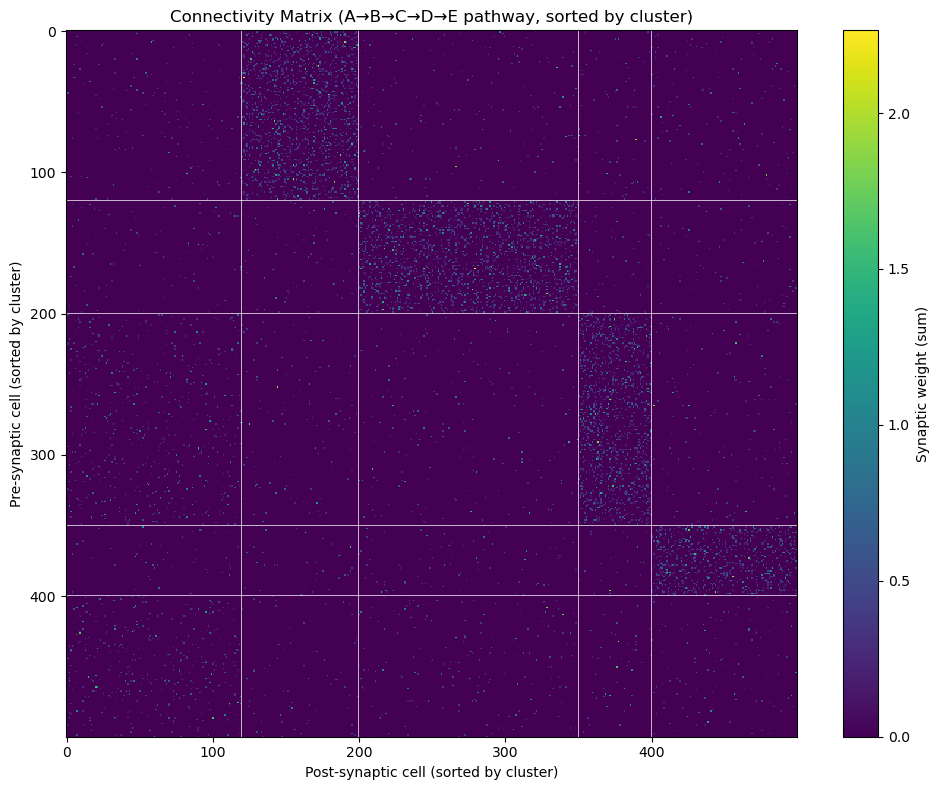

In [10]:
# =============================================================================
# 7. VALIDATION VISUAL - Connectivity matrix sorted by cluster
# =============================================================================
# Sort indices by cluster (A, B, C, D, E) so blocks are visible
sort_order = np.argsort([CLUSTER_LABELS.index(c) for c in cluster_assignments])
conn_sorted = connectivity_matrix[np.ix_(sort_order, sort_order)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conn_sorted, cmap='viridis', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Synaptic weight (sum)')
ax.set_xlabel('Post-synaptic cell (sorted by cluster)')
ax.set_ylabel('Pre-synaptic cell (sorted by cluster)')
ax.set_title('Connectivity Matrix (A→B→C→D→E pathway, sorted by cluster)')

# Add cluster boundaries
cumsum = np.cumsum(CLUSTER_SIZES)
for b in cumsum[:-1]:
    ax.axhline(b - 0.5, color='white', linewidth=0.5)
    ax.axvline(b - 0.5, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()